<a href="https://colab.research.google.com/github/Zineb9876/Projet-Deep-Learning/blob/main/Exercice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importation des modules
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [ ]:
# Chargement des données MNIST
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

print('X_train shape:', X_train.shape) # 60,000 images
print('X_train shape:', X_test.shape) # 10,000 images

# Normalisation des données
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

print(X_train[1,:,:])
print(X_test[1,:,:])

X_train shape: (60000, 28, 28)
X_train shape: (10000, 28, 28)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.  

1.  Normaliser les images permet au réseau de neurones d’apprendre plus rapidement et plus efficacement.

2.  Chaque pixel initialement entre 0 et 255 est divisé par 255 pour avoir des valeurs entre 0 et 1.

3.  MNIST contient 60 000 images pour l’entraînement et 10 000 images pour le test.

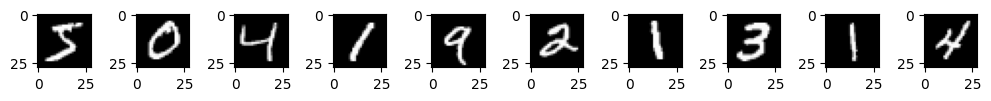

In [ ]:
# visualisation des donnees d'entres (X_train)
fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(10, 4))
for i in range(10):
  ax[i].imshow(X_train[i,:,:], cmap='gray')

plt.tight_layout()
plt.show()

1.  Permet de vérifier visuellement les données et leur format.

2.  Chaque image est en 28x28 pixels.

In [ ]:
# Configuration des couches du réseau
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), ## la couche d'entree
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10) ## la couche de sortie
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilation du modele
model.compile(optimizer='adam',
              loss= keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


1.  Optimiseur Adam : ajuste le taux d’apprentissage automatiquement.

2.  Loss : SparseCategoricalCrossentropy car les labels sont des entiers (0 à 9).

In [ ]:
# Entrainement du modele
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9837 - loss: 0.0499
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9873 - loss: 0.0390
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9900 - loss: 0.0313
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9923 - loss: 0.0244
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9933 - loss: 0.0219
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9939 - loss: 0.0175
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9945 - loss: 0.0171
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9947 - loss: 0.0154
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9954 - loss: 0.0136
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9955 - loss: 0.0136


In [ ]:
# Evaluation du modele
test_loss, test_acc = model.evaluate(X_test,  y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9744 - loss: 0.1070
Test accuracy: 0.9789000153541565


1. Permet de mesurer la généralisation du modèle sur des images jamais vues.

2. Une petite différence entre train et test accuracy est normale.

In [ ]:
# modele prédictif (pour valider le modele entraine)
prediction_model = keras.Sequential([model, keras.layers.Softmax()])
predict_proba = prediction_model.predict(X_test)
print(predict_proba[0])
predictions = np.argmax(predict_proba, axis=1)

print(predictions[:10])




313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[6.2458233e-11 2.3178094e-10 1.2564104e-10 4.1507753e-09 5.3958252e-14
 3.5320667e-14 4.9594830e-18 9.9999994e-01 4.6071450e-12 1.3912348e-09]
[7 2 1 0 4 1 4 9 5 9]


1. Softmax transforme les logits de sortie en probabilités (somme = 1).

2. argmax permet de choisir la classe avec la plus haute probabilité.

3. Permet de comparer directement prévisions vs vérité et de vérifier les erreurs.

# Nouvelle section